In [1]:
import os
import sys
import subprocess
import numpy as np
from IPython.display import Image, display


Note that the working directory will be set to ```main_dir``` (the base directory), not the notebooks directory. <br>
Libraries such as GPA and Force-Matching are located in ```scripts``` directory. <br>
So, change the working directory to ```os.chdir("scripts")``` or ```os.chdir("scripts/ForceMatching")``` for running GPA or Force-Matching in this notebook.

In [2]:
lib_dir = os.getcwd()
if "notebooks" in lib_dir:
    lib_dir = os.path.join(lib_dir[:-10], 'PROFET')
elif lib_dir == "/content":
    lib_dir = lib_dir + "/GPA-source_code"
os.chdir(lib_dir)
print(lib_dir)

main_dir = os.path.dirname(lib_dir)
sys.path.insert(0, main_dir)  # for util.utils
sys.path.insert(0, lib_dir)   # for models.velocityfield
data_dir = os.path.join(main_dir, 'data', '')

os.makedirs(os.path.join(main_dir, 'data'), exist_ok=True)
os.makedirs(os.path.join(main_dir, 'assets'), exist_ok=True)

from util.utils import (
    ResourceMonitor, contrast_colors,
    reduce_dimension, save_preprocessed_data, load_preprocessed_data, visualize_data,
    generate_animation, generate_W2distance_plot,
)

/Users/hyemin/Documents/source_code/ongoing/Trajectory-Inference/PROFET/PROFET
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : OpenMP library not found, it must be downloaded through Homebrew for apple Silicon chips
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


## Stem Cell Differentiation dataset

### Data property

* 5 snapshots at different timepoints (day 0, 1, 2, 3, 4)
* 100 genes · 456 total cells
* Training timepoints: `times=[0, 2, 4]`, `d_red=16`
* Cells per training tp: Day 0: 92 · Day 2: 93 · Day 4: 93
* Held-out / Intermediate: Day 1: 91 · Day 3: 87

### Data structure
Datasets are located in `data/stem_Cell_Differentiation` directory.

* `Data_0_gene_expression_matrix.txt` : Raw data matrix in $\mathbb{R}^{M \times N}$ composed of $M$ rows for individual samples and $N$ columns of different genes.
* `Data_0_Cells_Days_matrix.txt` : The entire dataset is divided into 5 classes which correspond to different days.

In [3]:
# Preprocessing function
def load_stem_cell_diff_dataset():
    import pandas as pd

    # gene_expression dataset => full_matrix
    GE_matrix_file = data_dir + 'Stem_Cell_Differentiation/Data_0_gene_expression_matrix.txt'
    if os.path.exists(GE_matrix_file):
        df = pd.read_table(GE_matrix_file, sep="\t")
        print(df)
        full_matrix = np.array(df)[:,1:]
    else:
        print("If full gene expression matrix is stored in the directory, load and view it.")

    # time information => time_label
    time_info_file = data_dir + 'Stem_Cell_Differentiation/Data_0_Cells_Days_matrix.txt'
    df_cls = pd.read_table(time_info_file, sep="\t")
    time_label = np.array(df_cls['day'])
    print("classes:", set(time_label))
        
    return full_matrix, time_label

           id      SOX2     ESRRB      UTF1     EPAS1     FOXQ1      KLF2  \
0      cell_0  1.245513  1.279713  1.417324  0.551417  0.000000  1.158272   
1      cell_1  1.219480  1.276735  1.546119  0.557738  0.000000  1.129090   
2      cell_2  1.273929  1.167757  1.554748  0.490467  0.000000  0.919075   
3      cell_3  1.290600  1.228051  1.225030  0.350676  0.000000  1.140910   
4      cell_4  1.592997  1.388465  1.775559  0.896887  0.000000  1.221018   
..        ...       ...       ...       ...       ...       ...       ...   
451  cell_451  0.000000  0.000000  0.208461  1.486076  0.715741  0.000000   
452  cell_452  0.000000  0.000000  0.037631  1.526674  1.071926  0.064867   
453  cell_453  0.000000  0.000000  0.711525  0.919148  0.868906  0.089821   
454  cell_454  0.000000  0.000000  0.095177  1.205572  0.771927  0.000000   
455  cell_455  0.000000  0.000000  0.449990  1.319348  0.960810  0.000000   

        GATA4     SOX17     NR0B1  ...    ZBTB44      ELF2      ETS1  \
0  

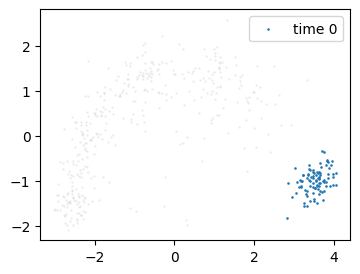

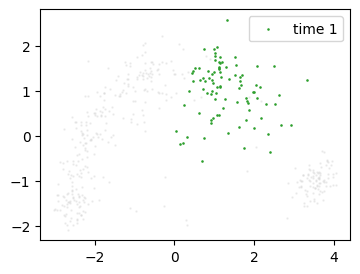

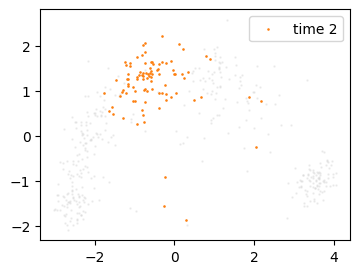

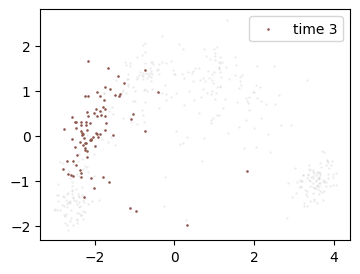

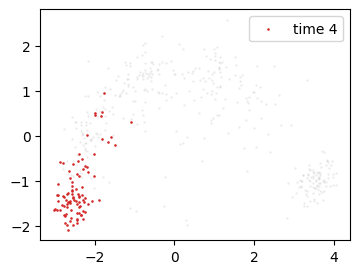

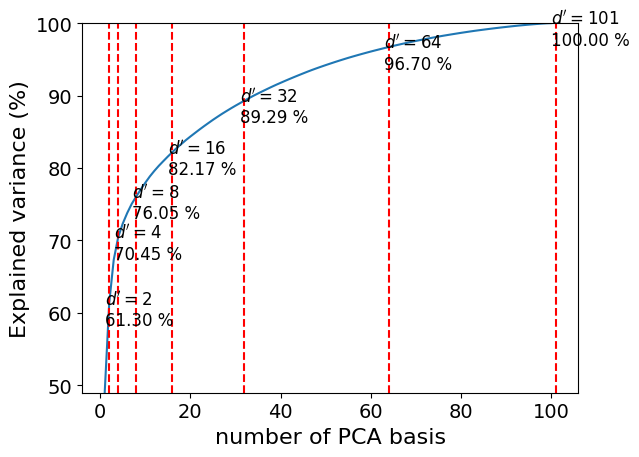

In [4]:
# Data preprocess
example_name = 'stem_cell_differentiation' # 
d_reds = [2, 4, 8, 16,32, 64,101] # [] or list of reduced dimensions
    
full_matrix, time_label = load_stem_cell_diff_dataset()
visualize_data(full_matrix, time_label, colors=contrast_colors)
try:
    pca, projected_matrix = reduce_dimension(full_matrix, d_reds, example_name)
    data = {'full_matrix': full_matrix, 'time_label': time_label, 'pca': pca, 'projected_matrix': projected_matrix}
except:
    data = {'full_matrix': full_matrix, 'time_label': time_label}
save_preprocessed_data(data, example_name)

In [5]:
from collections import Counter
cnt = Counter(time_label)

In [6]:
# Load precomputed preprocessed data
try:
    time_label, full_matrix, projected_matrix, pca = load_preprocessed_data(example_name)
except:
    time_label, full_matrix = load_preprocessed_data(example_name)

time_points = sorted(list(set(time_label)))

## PROFET

In [7]:
# PROFET step 1: GPA
d_red = 16
times = [0, 2, 4]
dimension_reduction = 'Y'
exp_no = "test"
exp_memo = f"dim{d_red}_{exp_no}"

result_dir = os.path.join(main_dir, "assets", example_name, exp_memo)
os.makedirs(result_dir, exist_ok=True)

# tunable parameters
adjust_lr_P_epochs = 'Y'    # 'Y' to auto-adjust lr_P and epochs w.r.t. dimensionality
                            # 'N' to use specified lr_P and epochs below
lr_P = 0.0025
epochs = 5000
specify_f_Lip_threshold = 'Y'    # 'Y' to stop when f_Lip divergence < threshold
f_Lip_threshold = 1e-4

In [8]:
os.chdir(lib_dir)

dimension_note = f'dim{d_red}-' if dimension_reduction in ['Y', 'yes'] else ''

with ResourceMonitor() as monitor:
    for i in range(len(times) - 1):
        cmd = (
            f"python3 run_GPA.py"
            f" --dataset {example_name}"
            f" --label {times[i]} {times[i+1]}"
            f" --N_dim {d_red}"
            f" --exp_no {exp_no}"
            f" --dimension_reduction {dimension_reduction}"
        )
        if adjust_lr_P_epochs in ['N', 'no']:
            cmd += f" --adjust_lr_P_epochs {adjust_lr_P_epochs} -lr_P {lr_P} --epochs {epochs}"
        if specify_f_Lip_threshold in ['Y', 'yes']:
            cmd += f" --f_Lip_threshold {f_Lip_threshold}"
        subprocess.run(cmd, shell=True, check=True)

monitor.report("PROFET GPA", dataset=example_name, d_red=d_red,
               filename=os.path.join(result_dir, "resources.txt"))

Data prepared.
Example specific step size = 0.0019569156770376695
iter   2000: loss = 1.0033974648, norm of dW = 1.79, kinetic energy of P = 0.1577679941, average learning rate for P = 0.001957
iter   4000: loss = 0.2293100357, norm of dW = 0.38, kinetic energy of P = 0.0765590197, average learning rate for P = 0.001957
total time 407.783s
Results saved at: /Users/hyemin/Documents/source_code/ongoing/Trajectory-Inference/PROFET/assets/stem_cell_differentiation/KL-Lipschitz_1.0000-0_2times-dim16-0093_0092-00-test.pickle
Data prepared.
Example specific step size = 0.0016585293119041073
iter   2000: loss = 0.2952398658, norm of dW = 0.31, kinetic energy of P = 0.1738375726, average learning rate for P = 0.001659
total time 204.363s
Results saved at: /Users/hyemin/Documents/source_code/ongoing/Trajectory-Inference/PROFET/assets/stem_cell_differentiation/KL-Lipschitz_1.0000-2_4times-dim16-0093_0093-00-test.pickle
[PROFET GPA] Wall-clock time : 619.45 s
[PROFET GPA] Peak GPU memory : N/A (no

In [9]:
# PROFET step 2: Force-Matching
intermediate_times = [1, 3]

if dimension_reduction in ['Y', 'yes']:
    dimension_note = f'dim{d_red}-'
else:
    dimension_note = ''
gpa_filenames = [
    f'KL-Lipschitz_1.0000-{times[0]}_{times[1]}times-{dimension_note}{cnt[times[1]]:04d}_{cnt[times[0]]:04d}-00-{exp_no}.pickle',
    f'KL-Lipschitz_1.0000-{times[1]}_{times[2]}times-{dimension_note}{cnt[times[2]]:04d}_{cnt[times[1]]:04d}-00-{exp_no}.pickle',
]

gpa_filenames_join = " ".join(gpa_filenames)
times_join = " ".join([str(t) for t in times])


In [10]:
os.chdir(lib_dir)
cmd = (
    f"python3 run_ForceMatching.py"
    f" --dataset {example_name}"
    f" --ts {times_join}"
    f" --exp_memo {exp_memo}"
    f" --files {gpa_filenames_join}"
)

with ResourceMonitor() as monitor:
    subprocess.run(cmd, shell=True, check=True)

monitor.report("PROFET ForceMatching", dataset=example_name, d_red=d_red,
               filename=os.path.join(result_dir, "resources.txt"))

GPA time = [0.0, 7.680894032372852, 12.445848745473352], Ratios between GPA times = [1.0, 0.6203645946705589]
Physical time = [0.0, 2.0, 4.0], Converted time = [0.0, 7.680894032372852, 15.361788064745705]
Iteration 2000, Loss: 0.071163
Iteration 4000, Loss: 0.066740
Iteration 6000, Loss: 0.062212
Iteration 8000, Loss: 0.051860
Iteration 10000, Loss: 0.056582
Iteration 12000, Loss: 0.041566
Iteration 14000, Loss: 0.054591
Iteration 16000, Loss: 0.038208
Iteration 18000, Loss: 0.045757
Iteration 20000, Loss: 0.030408
Results saved at: /Users/hyemin/Documents/source_code/ongoing/Trajectory-Inference/PROFET/assets/stem_cell_differentiation/dim16_test/
Total time: 74.38029623031616 sec
[PROFET ForceMatching] Wall-clock time : 77.44 s
[PROFET ForceMatching] Peak GPU memory : N/A (no CUDA device)
[PROFET ForceMatching] Peak CPU RAM    : 0.102 GB
[PROFET ForceMatching] Dataset         : stem_cell_differentiation
[PROFET ForceMatching] Dimensionality  : 16


In [11]:
from models.velocityfield import VelocityField

# load velocityfield
velocity_net, p = VelocityField.load(os.path.join(main_dir, "assets", example_name, exp_memo, ""))

# integrate ODE
dt = p['numerical_ts'][-1]/200
numerical_dt = dt
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]
input_data = full_matrix[time_label==0,:] if dimension_reduction in ['N', 'no'] else projected_matrix[time_label==0, :d_red]
X1_trpts = velocity_net.integrate(input_data, T=p['numerical_ts'][-1], dt=dt)

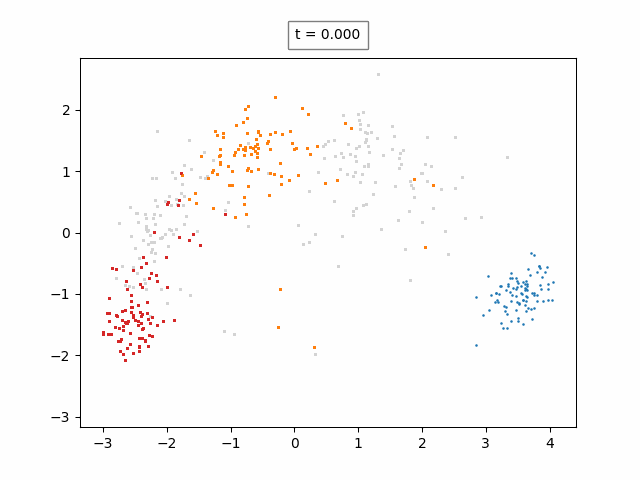

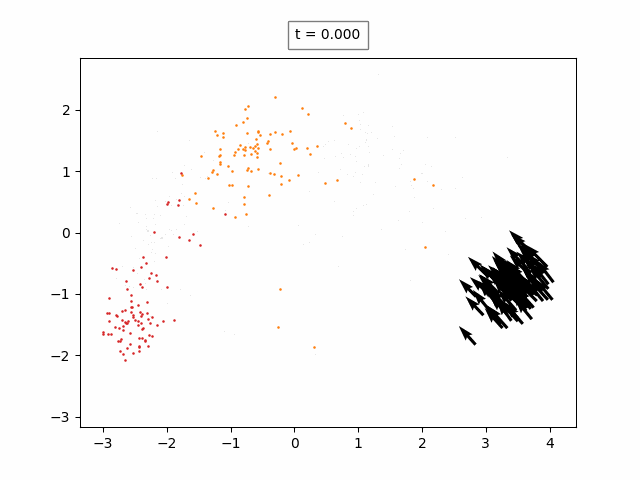

minimum values are obtained at x= [0.0, 1.12, 2.18, 3.0, 3.84]


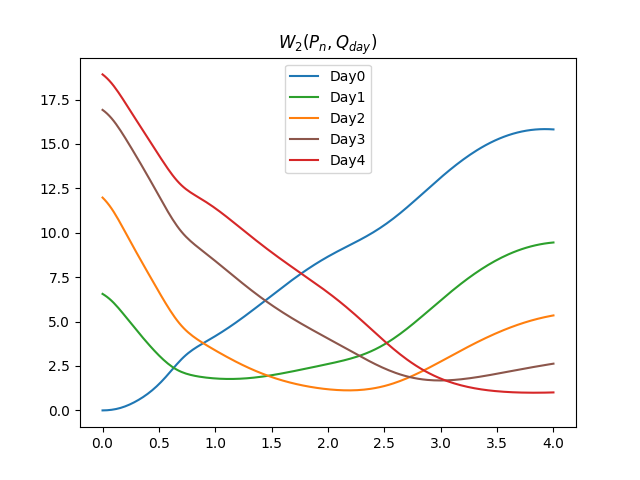

<Figure size 640x480 with 0 Axes>

In [12]:
img_src1 = os.path.join(main_dir, "assets", example_name, f"{exp_memo}-movie-particles.gif")
img_src2 = os.path.join(main_dir, "assets", example_name, f"{exp_memo}-movie-velocities.gif")
img_src3 = os.path.join(main_dir, "assets", example_name, f"{exp_memo}-w2distances.png")

generate_animation(example_name, times, intermediate_times, X1_trpts,
                   img_src1, d_red, True, colors=contrast_colors, plot_vectorfield=False)
display(Image(filename=img_src1))

generate_animation(example_name, times, intermediate_times, X1_trpts,
                   img_src2, d_red, True, colors=contrast_colors, plot_vectorfield=True)
display(Image(filename=img_src2))

generate_W2distance_plot(example_name, times, intermediate_times, X1_trpts,
                         img_src3, d_red, True, colors=contrast_colors)
display(Image(filename=img_src3))

## Downstream Analysis — Trajectory Visualization and Subtrajectory Classification

Visualizes full reconstructed trajectories and classifies them into subtrajectories based on **fate cell state** (target clustering) for the Stem Cell Differentiation dataset.

**Prerequisites:**
- PROFET section above must have been run so that `X1_trpts`, `p`, `physical_dt`, `full_matrix`, `time_label`, `time_points`, `projected_matrix`, and `pca` are in scope.
- The cluster labels (`{exp_memo}_X1_hat_clusters.csv`) generated here are required by the Gene Expression Dynamics section below.

In [ ]:
import pandas as pd
from sklearn import decomposition
from util.downstream import (
    generate_static_trajectory_plots_three_timepoints,
    classify_X1_hat,
    generate_static_cluster_plot_target,
)

# d_red-component PCA for trajectory visualization and inverse_transform
pca_d = decomposition.PCA(n_components=d_red, random_state=0)
pca_d.fit(full_matrix)

# Per-timepoint full expression matrices
mats = {t: full_matrix[time_label == t].astype(float) for t in time_points}

source_t, target_t = times[0], times[-1]  # 0, 4
optimal_k = 2   # number of subtrajectory classes; adjust based on biology
start_i = 0
index = 10

### Static Trajectory Visualization

Generates static scatter plots of the full reconstructed trajectory: one with trajectory snapshots (coloured by time via viridis gradient) and one showing only the training/test data snapshots.

In [ ]:
output_with = os.path.join(result_dir, f"{exp_memo}_static_trajectory_with_snapshots.png")
output_without = os.path.join(result_dir, f"{exp_memo}_static_trajectory_without_snapshots.png")

generate_static_trajectory_plots_three_timepoints(
    pca=pca_d,
    physical_dt=physical_dt,
    days=times,
    intermediate_days=intermediate_times,
    X1_trpts=X1_trpts,
    mats=mats,
    d_red=d_red,
    output_file_with_snapshots=output_with,
    output_file_without_snapshots=output_without,
)
display(Image(filename=output_with))
display(Image(filename=output_without))

### Subtrajectory Classification by Fate State

Clusters cells at the **target** time point into `optimal_k` groups using K-means, then assigns each trajectory to the fate cluster it converges toward. Produces an animated GIF of trajectories coloured by fate group and a static initial-state figure.

In [ ]:
output_gif = os.path.join(result_dir, f"{exp_memo}_classify_x1_hat_trajectory.gif")
output_png = os.path.join(result_dir, f"{exp_memo}_fate_state_with_background_x1.png")

classify_X1_hat(
    full_matrix, pca_d, source_t, target_t, X1_trpts, mats,
    optimal_k, start_i, index, p,
    reverse=False, intermediate_t=intermediate_times,
    d_red=d_red, random_state=42, exp_memo=exp_memo,
    output_file=output_gif, output_file_2=output_png,
)
display(Image(filename=output_png))

### Static Subtrajectory Plot (by Fate State)

Generates a static plot of all trajectory snapshots coloured by fate subgroup. Cluster labels are saved to `{exp_memo}_X1_hat_clusters.csv` for use in the Gene Expression Dynamics section below.

In [ ]:
cluster_output_file = os.path.join(result_dir, f"{exp_memo}_static_cluster_plot_target.png")

X1_hat_labels = generate_static_cluster_plot_target(
    pca_d, source_t, target_t, X1_trpts, mats,
    optimal_k, start_i, index=1, p=p,
    reverse=False, intermediate_t=intermediate_times,
    d_red=d_red, random_state=42, exp_memo=exp_memo,
    output_file=cluster_output_file,
)
display(Image(filename=cluster_output_file))

# Save cluster labels
cluster_save_path = os.path.join(result_dir, f"{exp_memo}_X1_hat_clusters.csv")
df_clusters = pd.DataFrame({
    "Cell_Index": np.arange(len(X1_hat_labels)),
    "Cluster_Label": X1_hat_labels,
})
df_clusters.to_csv(cluster_save_path, index=False)
print(f"Cluster labels saved to {cluster_save_path}")

## Downstream Analysis — Reconstruction of Gene Expression Dynamics

The following cells reconstruct gene expression dynamics in the original high-dimensional gene space using the PROFET trajectory inferred above.

**Prerequisites:**
- Preprocessing and PROFET sections above must have been run (or loaded) so that `X1_trpts`, `velocity_net`, `p`, `full_matrix`, `time_label`, `time_points`, `projected_matrix`, and `pca` are in scope.
- Subtrajectory cluster file (`{exp_memo}_X1_hat_clusters.csv`) must exist in `result_dir` — generated by the trajectory visualisation / subtrajectory classification notebook.

In [ ]:
# Downstream analysis setup
import pandas as pd
from sklearn import decomposition

# d_red-component PCA for gene expression reconstruction via inverse_transform
pca_d = decomposition.PCA(n_components=d_red, random_state=0)
pca_d.fit(full_matrix)

# Per-timepoint full expression matrices
mats = {t: full_matrix[time_label == t].astype(float) for t in time_points}

# Gene names from the expression matrix file
gene_file = data_dir + 'Stem_Cell_Differentiation/Data_0_gene_expression_matrix.txt'
df_genes = pd.read_table(gene_file, sep="\t")
gene_names = df_genes.columns[1:].tolist()
print(f"Number of genes: {len(gene_names)}")

# Import downstream analysis functions
from util.downstream import (
    Average_gene_dynamics_whole_saveonly,
    Average_gene_dynamics_whole_saveonly_with_violin_plot_sample_3_stem,
    Compute_and_Plot_FoldChange_MeanDiff_PValues,
    difference_of_means_stem,
    Average_gene_dynamics_whole_saveonly_single_trajectory_mESC,
    Compare_Distribution_Trajectories_Intermediate_mESC,
)

source_t, target_t = times[0], times[-1]  # 0, 4
intermediate_t = intermediate_times        # [1, 3]
optimal_k = 2  # number of subtrajectory classes
max_i = 200
index = 1

### Average Gene Dynamics

Mean gene expression over time for each gene, reconstructed from PROFET trajectories, with a 95% confidence interval. Compared against observed means at source, intermediate, and target time points.

In [ ]:
for gene in gene_names:
    print(f"Processing gene: {gene}")
    try:
        img_src = os.path.join(result_dir, f"average_gene_expression_{gene}.png")
        Average_gene_dynamics_whole_saveonly(
            pca_d, gene_names, source_t, target_t, X1_trpts, mats,
            gene, index, p, max_i,
            intermediate_t=intermediate_t, img_src=img_src,
        )
    except Exception as e:
        print(f"  Error: {e}")

### Average Gene Dynamics by Subtrajectory

Mean gene expression per subtrajectory (classified by cell fate) with violin plots. Requires subtrajectory cluster annotations saved at `{result_dir}/{exp_memo}_X1_hat_clusters.csv` from the trajectory visualisation notebook.

In [ ]:
cluster_save_path = os.path.join(result_dir, f"{exp_memo}_X1_hat_clusters.csv")

for gene in gene_names:
    print(f"Processing gene: {gene}")
    try:
        img_src = os.path.join(result_dir, f"subtrajectories_violin_{gene}.png")
        Average_gene_dynamics_whole_saveonly_with_violin_plot_sample_3_stem(
            pca_d, gene_names, source_t, target_t, X1_trpts, mats,
            optimal_k, gene, index, p, max_i,
            intermediate_t=intermediate_t, img_src=img_src,
            cluster_save_path=cluster_save_path,
        )
    except Exception as e:
        print(f"  Error: {e}")

### Statistical Analysis: Fold Change, Mean Differences, p-values

Computes per-gene statistics across subtrajectories and saves CSVs + plots to `result_dir/subtraj/`.

In [ ]:
subtraj_dir = os.path.join(result_dir, 'subtraj')
os.makedirs(subtraj_dir, exist_ok=True)

for gene in gene_names:
    Compute_and_Plot_FoldChange_MeanDiff_PValues(
        pca_d, gene_names, X1_trpts, gene, index, p, max_i,
        subtraj_dir=subtraj_dir,
        cluster_save_path=cluster_save_path,
    )

difference_of_means_stem(gene_names, subtraj_dir)

### Single-Cell Gene Expression Dynamics

Plots gene expression trajectories for every individual cell, grouped by subtrajectory class (cell fate).

In [ ]:
for gene in gene_names:
    print(f"Processing gene: {gene}")
    try:
        subgroup_output_file = os.path.join(result_dir, f"single_cell_trajectories_{gene}.png")
        Average_gene_dynamics_whole_saveonly_single_trajectory_mESC(
            pca_d, gene_names, source_t, target_t, X1_trpts, mats,
            optimal_k, gene, index, p, max_i,
            intermediate_t=intermediate_t,
            subgroup_output_file=subgroup_output_file,
            cluster_save_path=cluster_save_path,
        )
    except Exception as e:
        print(f"  Error: {e}")

### Distribution Comparison at Intermediate Time Points

KDE density plots comparing predicted gene expression distributions from PROFET trajectories against observed data at intermediate time points (days 1 and 3).

In [ ]:
for gene in gene_names:
    print(f"Processing gene: {gene}")
    try:
        output_file = os.path.join(result_dir, f"KDE_distribution_{gene}.png")
        Compare_Distribution_Trajectories_Intermediate_mESC(
            pca_d, gene_names, source_t, target_t, X1_trpts, mats,
            gene, p, intermediate_t=intermediate_t, output_file=output_file,
        )
    except Exception as e:
        print(f"  Error: {e}")